<a href="https://colab.research.google.com/github/newazkhn/FloodPINN/blob/main/notebooks/04_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 04_preprocessing.ipynb — Chunked Processing Version
# ============================================================
# APPROACH : Stream data in small chunks (1024x1024 pixels)
#            Never load full tile into RAM
#            Process each chunk, extract chips, save
#            Memory usage stays under 2GB at all times
#
# This is the professional approach used in large-scale
# remote sensing research with limited compute resources
# ============================================================

!pip install rasterio -q

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import rasterio
import rasterio.windows
import os
import gc           # Garbage collector — frees RAM
import glob
import torch
import random
import matplotlib.pyplot as plt

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'cpu')
print(f"Device     : {device}")
if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory
    print(f"GPU Memory : {mem/1e9:.1f} GB")
    print("✓ GPU ready")

# ── Paths ────────────────────────────────────────────────
DRIVE_BASE    = '/content/drive/MyDrive'
INPUT_FOLDER  = f'{DRIVE_BASE}/FloodPINN_Pakistan'
OUTPUT_FOLDER = f'{DRIVE_BASE}/FloodPINN_Chips'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Find all 4 input tiles
tile_pattern = (f'{INPUT_FOLDER}/'
                f'Pakistan_2022_input_sindh-*.tif')
input_tiles  = sorted(glob.glob(tile_pattern))
labels_file  = (f'{INPUT_FOLDER}/'
                f'Pakistan_2022_labels_sindh.tif')

print(f"\nInput tiles : {len(input_tiles)} found")
for t in input_tiles:
    size = os.path.getsize(t)/1e9
    print(f"  {os.path.basename(t)} — {size:.1f} GB")

size = os.path.getsize(labels_file)/1e6
print(f"\nLabels file : {size:.1f} MB")
print("\n✓ Setup complete — ready for chunked processing")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device     : cuda
GPU        : Tesla T4
GPU Memory : 15.6 GB
✓ GPU ready

Input tiles : 4 found
  Pakistan_2022_input_sindh-0000000000-0000000000.tif — 5.6 GB
  Pakistan_2022_input_sindh-0000000000-0000011776.tif — 3.1 GB
  Pakistan_2022_input_sindh-0000011776-0000000000.tif — 3.8 GB
  Pakistan_2022_input_sindh-0000011776-0000011776.tif — 2.3 GB

Labels file : 12.3 MB

✓ Setup complete — ready for chunked processing


In [2]:
# ============================================================
# Inspect tile metadata — no data loading
# ============================================================

band_names = [
    'SAR_VV_before', 'SAR_VH_before',
    'SAR_VV_flood',  'SAR_VH_flood',
    'MNDWI_before',  'DEM',
    'Slope',         'HAND'
]

print("Tile inspection (metadata only — no RAM used):\n")

all_tile_info = []

for i, tile_path in enumerate(input_tiles):
    with rasterio.open(tile_path) as src:
        info = {
            'path'      : tile_path,
            'height'    : src.height,
            'width'     : src.width,
            'bands'     : src.count,
            'crs'       : src.crs,
            'transform' : src.transform,
            'bounds'    : src.bounds,
            'dtype'     : src.dtypes[0]
        }
        all_tile_info.append(info)

        print(f"Tile {i+1}: {os.path.basename(tile_path)}")
        print(f"  Size      : {info['height']} x "
              f"{info['width']} pixels")
        print(f"  Bands     : {info['bands']}")
        print(f"  Dtype     : {info['dtype']}")
        print(f"  Bounds    : {info['bounds']}\n")

# Inspect labels
with rasterio.open(labels_file) as src:
    print(f"Labels file:")
    print(f"  Size  : {src.height} x {src.width}")
    print(f"  Dtype : {src.dtypes[0]}")
    print(f"  CRS   : {src.crs}")

print("\n✓ Inspection complete — 0 MB RAM used for data")

Tile inspection (metadata only — no RAM used):

Tile 1: Pakistan_2022_input_sindh-0000000000-0000000000.tif
  Size      : 11776 x 11776 pixels
  Bands     : 8
  Dtype     : float32
  Bounds    : BoundingBox(left=66.49994486362947, bottom=25.849651121238118, right=69.67351309936691, top=29.023219356975563)

Tile 2: Pakistan_2022_input_sindh-0000000000-0000011776.tif
  Size      : 11776 x 6778 pixels
  Bands     : 8
  Dtype     : float32
  Bounds    : BoundingBox(left=69.67351309936691, bottom=25.849651121238118, right=71.50014739809555, top=29.023219356975563)

Tile 3: Pakistan_2022_input_sindh-0000011776-0000000000.tif
  Size      : 8719 x 11776 pixels
  Bands     : 8
  Dtype     : float32
  Bounds    : BoundingBox(left=66.49994486362947, bottom=23.499927832566684, right=69.67351309936691, top=25.849651121238118)

Tile 4: Pakistan_2022_input_sindh-0000011776-0000011776.tif
  Size      : 8719 x 6778 pixels
  Bands     : 8
  Dtype     : float32
  Bounds    : BoundingBox(left=69.673513099

In [3]:
# ============================================================
# Extract chips using chunked streaming
# ============================================================
# KEY IDEA : Read one CHUNK_SIZE x CHUNK_SIZE window
#            at a time from each tile
#            Extract 512x512 chips from that chunk
#            Save chips immediately to disk
#            Delete chunk from RAM before next chunk
#            RAM usage stays constant ~1-2GB
# ============================================================

CHIP_SIZE  = 512    # Final chip size
CHUNK_SIZE = 2048   # Read this many pixels at a time
                    # Adjust down to 1024 if still crashes
STRIDE     = 256    # Step between chips (50% overlap)
MIN_VALID  = 0.7    # Min valid pixel fraction per chip
MIN_FLOOD  = 0.02   # Min flood pixel fraction per chip

# Temporary storage — save to disk every 100 chips
BATCH_SAVE = 100

all_X_files = []   # Paths to saved batch files
all_y_files = []

total_chips    = 0
skipped_nodata = 0
skipped_flood  = 0
batch_X        = []
batch_y        = []
batch_num      = 0

print(f"Starting chunked extraction...")
print(f"  Chip size  : {CHIP_SIZE}x{CHIP_SIZE}")
print(f"  Chunk size : {CHUNK_SIZE}x{CHUNK_SIZE}")
print(f"  Stride     : {STRIDE}")
print(f"  Min valid  : {MIN_VALID*100:.0f}%")
print(f"  Min flood  : {MIN_FLOOD*100:.0f}%")
print(f"  Batch save : every {BATCH_SAVE} chips\n")

def save_batch(batch_X, batch_y, batch_num):
    """Save current batch to disk and free RAM."""
    if len(batch_X) == 0:
        return
    X_path = f'{OUTPUT_FOLDER}/batch_X_{batch_num:04d}.npy'
    y_path = f'{OUTPUT_FOLDER}/batch_y_{batch_num:04d}.npy'
    np.save(X_path, np.array(batch_X, dtype=np.float32))
    np.save(y_path, np.array(batch_y, dtype=np.uint8))
    all_X_files.append(X_path)
    all_y_files.append(y_path)
    print(f"  Saved batch {batch_num:04d} — "
          f"{len(batch_X)} chips → {X_path}")
    return [], []   # Return empty lists

# Process each tile
for tile_idx, tile_path in enumerate(input_tiles):
    tile_name = os.path.basename(tile_path)
    print(f"\n{'='*50}")
    print(f"Processing tile {tile_idx+1}/"
          f"{len(input_tiles)}: {tile_name}")

    with rasterio.open(tile_path) as src_input, \
         rasterio.open(labels_file) as src_labels:

        H = src_input.height
        W = src_input.width
        print(f"Tile dimensions: {H} x {W}")

        # Iterate over chunks
        chunk_row = 0
        while chunk_row < H:
            chunk_h = min(CHUNK_SIZE, H - chunk_row)

            chunk_col = 0
            while chunk_col < W:
                chunk_w = min(CHUNK_SIZE, W - chunk_col)

                # Skip chunks smaller than one chip
                if chunk_h < CHIP_SIZE or \
                   chunk_w < CHIP_SIZE:
                    chunk_col += CHUNK_SIZE
                    continue

                # Read this chunk from input tile
                chunk_window = rasterio.windows.Window(
                    chunk_col, chunk_row,
                    chunk_w, chunk_h)

                try:
                    chunk_X = src_input.read(
                        window=chunk_window
                    ).astype(np.float32)
                except Exception as e:
                    chunk_col += CHUNK_SIZE
                    continue

                # Extract chips from this chunk
                for row in range(
                    0, chunk_h - CHIP_SIZE + 1, STRIDE):
                    for col in range(
                        0, chunk_w - CHIP_SIZE + 1, STRIDE):

                        # Extract chip from chunk
                        x_chip = chunk_X[
                            :,
                            row:row+CHIP_SIZE,
                            col:col+CHIP_SIZE
                        ]

                        # Skip if too many invalid pixels
                        valid = np.isfinite(x_chip).mean()
                        if valid < MIN_VALID:
                            skipped_nodata += 1
                            continue

                        # Get corresponding label chip
                        # Calculate absolute pixel position
                        abs_col = chunk_col + col
                        abs_row = chunk_row + row

                        label_window = \
                            rasterio.windows.Window(
                                abs_col, abs_row,
                                CHIP_SIZE, CHIP_SIZE)

                        try:
                            y_chip = src_labels.read(
                                1,
                                window=label_window,
                                out_shape=(
                                    CHIP_SIZE, CHIP_SIZE),
                                resampling=rasterio.enums
                                .Resampling.nearest
                            ).astype(np.uint8)
                        except Exception:
                            y_chip = np.zeros(
                                (CHIP_SIZE, CHIP_SIZE),
                                dtype=np.uint8)

                        # Skip chips with no flood pixels
                        flood_frac = (y_chip==1).mean()
                        if flood_frac < MIN_FLOOD:
                            skipped_flood += 1
                            continue

                        # Clean NaN values
                        x_chip = np.nan_to_num(
                            x_chip, nan=0.0)

                        batch_X.append(x_chip)
                        batch_y.append(y_chip)
                        total_chips += 1

                        # Save batch and free RAM
                        if len(batch_X) >= BATCH_SAVE:
                            batch_X, batch_y = save_batch(
                                batch_X, batch_y, batch_num)
                            batch_num += 1
                            gc.collect()  # Force free RAM

                # Free chunk from RAM immediately
                del chunk_X
                gc.collect()

                chunk_col += CHUNK_SIZE

            chunk_row += CHUNK_SIZE
            print(f"  Chunk row {chunk_row}/{H} — "
                  f"chips so far: {total_chips}")

# Save final batch
if len(batch_X) > 0:
    save_batch(batch_X, batch_y, batch_num)
    batch_num += 1

print(f"\n{'='*50}")
print(f"Extraction complete!")
print(f"  Total chips    : {total_chips}")
print(f"  Skipped nodata : {skipped_nodata}")
print(f"  Skipped flood  : {skipped_flood}")
print(f"  Batch files    : {batch_num}")
print(f"\nFiles saved to: {OUTPUT_FOLDER}")

Starting chunked extraction...
  Chip size  : 512x512
  Chunk size : 2048x2048
  Stride     : 256
  Min valid  : 70%
  Min flood  : 2%
  Batch save : every 100 chips


Processing tile 1/4: Pakistan_2022_input_sindh-0000000000-0000000000.tif
Tile dimensions: 11776 x 11776
  Saved batch 0000 — 100 chips → /content/drive/MyDrive/FloodPINN_Chips/batch_X_0000.npy
  Chunk row 2048/11776 — chips so far: 143
  Saved batch 0001 — 100 chips → /content/drive/MyDrive/FloodPINN_Chips/batch_X_0001.npy
  Saved batch 0002 — 100 chips → /content/drive/MyDrive/FloodPINN_Chips/batch_X_0002.npy
  Chunk row 4096/11776 — chips so far: 375
  Saved batch 0003 — 100 chips → /content/drive/MyDrive/FloodPINN_Chips/batch_X_0003.npy
  Saved batch 0004 — 100 chips → /content/drive/MyDrive/FloodPINN_Chips/batch_X_0004.npy
  Chunk row 6144/11776 — chips so far: 591
  Saved batch 0005 — 100 chips → /content/drive/MyDrive/FloodPINN_Chips/batch_X_0005.npy
  Saved batch 0006 — 100 chips → /content/drive/MyDrive/FloodPINN

In [1]:
# ============================================================
# Cell 4 — Memory-safe normalisation and splitting
# ============================================================
# APPROACH : Never load all data at once
#            Step 1: Compute norm stats from small samples
#            Step 2: Stream batches directly into train/val/test
#            Step 3: Save each split incrementally
#            MAX RAM used at any time: ~2GB
# ============================================================

import numpy as np
import os
import gc
import glob

OUTPUT_FOLDER = '/content/drive/MyDrive/FloodPINN_Chips'

# ── Step 1: Find all saved batch files ──────────────────
X_batch_files = sorted(glob.glob(
    f'{OUTPUT_FOLDER}/batch_X_*.npy'))
y_batch_files = sorted(glob.glob(
    f'{OUTPUT_FOLDER}/batch_y_*.npy'))

print(f"Found {len(X_batch_files)} batch files")

# Count total chips without loading data
total_chips = 0
batch_sizes = []
for f in X_batch_files:
    arr = np.load(f, mmap_mode='r')  # mmap = no RAM used
    batch_sizes.append(len(arr))
    total_chips += len(arr)
    del arr

print(f"Total chips : {total_chips}")
print(f"Batch sizes : {batch_sizes[:5]}... "
      f"(showing first 5)")

# ── Step 2: Compute normalisation stats ─────────────────
# Sample 10% of chips from each batch — very low RAM
print("\nComputing normalisation statistics...")
print("(sampling 10% of data — minimal RAM)")

band_names = [
    'SAR_VV_before', 'SAR_VH_before',
    'SAR_VV_flood',  'SAR_VH_flood',
    'MNDWI_before',  'DEM',
    'Slope',         'HAND'
]

# Collect small sample for stats
sample_bands = [[] for _ in range(8)]

for X_file in X_batch_files:
    X_batch = np.load(X_file, mmap_mode='r')
    n = len(X_batch)
    # Take every 10th chip
    sample_idx = range(0, n, 10)
    for i in sample_idx:
        for b in range(8):
            sample_bands[b].append(
                X_batch[i, b].flatten())
    del X_batch
    gc.collect()

# Compute percentile stats per band
norm_stats = {}
print("\nNormalisation statistics:")
for b, name in enumerate(band_names):
    all_vals = np.concatenate(sample_bands[b])
    b_min = float(np.percentile(all_vals, 2))
    b_max = float(np.percentile(all_vals, 98))
    norm_stats[name] = {'min': b_min, 'max': b_max}
    print(f"  {name:20s} "
          f"min={b_min:.3f} max={b_max:.3f}")
    del all_vals

# Free sample memory
del sample_bands
gc.collect()

# Save norm stats
np.save(f'{OUTPUT_FOLDER}/norm_stats.npy', norm_stats)
print("\n✓ Norm stats saved")

# ── Step 3: Shuffle batch order ──────────────────────────
print("\nShuffling batch order...")
np.random.seed(42)
batch_order = list(range(len(X_batch_files)))
np.random.shuffle(batch_order)

# Calculate split points
n_train = int(0.7 * total_chips)
n_val   = int(0.2 * total_chips)
n_test  = total_chips - n_train - n_val

print(f"\nDataset splits:")
print(f"  Train : {n_train} chips (70%)")
print(f"  Val   : {n_val} chips (20%)")
print(f"  Test  : {n_test} chips (10%)")

# ── Step 4: Stream batches into splits ───────────────────
print("\nStreaming batches into train/val/test splits...")
print("(processing one batch at a time — low RAM)")

# Initialise split storage files
splits = {
    'train': {'X': [], 'y': [], 'count': 0,
              'limit': n_train},
    'val'  : {'X': [], 'y': [], 'count': 0,
              'limit': n_val},
    'test' : {'X': [], 'y': [], 'count': 0,
              'limit': n_test},
}

split_order = ['train', 'val', 'test']
current_split = 0
chips_processed = 0

# Track saved file parts
train_parts = []
val_parts   = []
test_parts  = []

def flush_split(split_name, data_X, data_y, part_num):
    """Save split buffer to disk."""
    if len(data_X) == 0:
        return
    X_path = (f'{OUTPUT_FOLDER}/'
               f'{split_name}_X_part{part_num:04d}.npy')
    y_path = (f'{OUTPUT_FOLDER}/'
               f'{split_name}_y_part{part_num:04d}.npy')
    np.save(X_path, np.array(data_X, dtype=np.float32))
    np.save(y_path, np.array(data_y, dtype=np.uint8))
    return X_path, y_path

part_counters = {'train': 0, 'val': 0, 'test': 0}
split_buffers_X = {'train': [], 'val': [], 'test': []}
split_buffers_y = {'train': [], 'val': [], 'test': []}
split_counts  = {'train': 0, 'val': 0, 'test': 0}
split_limits  = {'train': n_train,
                 'val'  : n_val,
                 'test' : n_test}
split_parts   = {'train': [], 'val': [], 'test': []}

BUFFER_SIZE = 200  # Save buffer every 200 chips

for batch_idx in batch_order:
    X_file = X_batch_files[batch_idx]
    y_file = y_batch_files[batch_idx]

    X_batch = np.load(X_file).astype(np.float32)
    y_batch = np.load(y_file).astype(np.uint8)

    # Normalise this batch
    for b, name in enumerate(band_names):
        b_min = norm_stats[name]['min']
        b_max = norm_stats[name]['max']
        X_batch[:, b] = np.clip(
            (X_batch[:, b] - b_min) /
            (b_max - b_min + 1e-8), 0, 1)

    # Assign each chip to correct split
    for chip_idx in range(len(X_batch)):
        # Determine which split this chip goes to
        assigned = False
        for split in split_order:
            if split_counts[split] < split_limits[split]:
                split_buffers_X[split].append(
                    X_batch[chip_idx])
                split_buffers_y[split].append(
                    y_batch[chip_idx])
                split_counts[split] += 1
                assigned = True
                break

        # Flush buffer if large enough
        for split in split_order:
            if len(split_buffers_X[split]) >= BUFFER_SIZE:
                paths = flush_split(
                    split,
                    split_buffers_X[split],
                    split_buffers_y[split],
                    part_counters[split])
                if paths:
                    split_parts[split].append(paths)
                part_counters[split] += 1
                split_buffers_X[split] = []
                split_buffers_y[split] = []
                gc.collect()

    del X_batch, y_batch
    gc.collect()

    chips_processed += batch_sizes[batch_idx]
    if batch_idx % 10 == 0:
        print(f"  Processed batch {batch_idx} — "
              f"train:{split_counts['train']} "
              f"val:{split_counts['val']} "
              f"test:{split_counts['test']}")

# Flush remaining buffers
for split in split_order:
    if len(split_buffers_X[split]) > 0:
        paths = flush_split(
            split,
            split_buffers_X[split],
            split_buffers_y[split],
            part_counters[split])
        if paths:
            split_parts[split].append(paths)

print(f"\n✓ Splitting complete!")
print(f"  Train parts : {part_counters['train']}")
print(f"  Val parts   : {part_counters['val']}")
print(f"  Test parts  : {part_counters['test']}")

Found 29 batch files
Total chips : 2801
Batch sizes : [100, 100, 100, 100, 100]... (showing first 5)

Computing normalisation statistics...
(sampling 10% of data — minimal RAM)

Normalisation statistics:
  SAR_VV_before        min=-21.160 max=-3.980
  SAR_VH_before        min=-29.895 max=-11.497
  SAR_VV_flood         min=-23.414 max=-4.382
  SAR_VH_flood         min=-30.143 max=-12.161
  MNDWI_before         min=-0.454 max=0.585
  DEM                  min=0.000 max=1611.000
  Slope                min=0.000 max=22.114
  HAND                 min=0.000 max=129.300

✓ Norm stats saved

Shuffling batch order...

Dataset splits:
  Train : 1960 chips (70%)
  Val   : 560 chips (20%)
  Test  : 281 chips (10%)

Streaming batches into train/val/test splits...
(processing one batch at a time — low RAM)
  Processed batch 0 — train:800 val:0 test:0
  Processed batch 20 — train:1960 val:341 test:0
  Processed batch 10 — train:1960 val:541 test:0

✓ Splitting complete!
  Train parts : 9
  Val parts  

In [2]:
# ============================================================
# Cell 5 — Save splits using HDF5 (memory safe)
# ============================================================
# HDF5 writes data incrementally to disk
# Never needs full dataset in RAM
# PyTorch DataLoader reads directly from HDF5
# Perfect for large remote sensing datasets
# ============================================================

!pip install h5py -q

import h5py
import numpy as np
import glob
import os
import gc

OUTPUT_FOLDER = '/content/drive/MyDrive/FloodPINN_Chips'
CHIP_SIZE     = 512
N_BANDS       = 8

# ── Count total chips per split ──────────────────────────
print("Counting chips per split...")

split_X_parts = {}
split_y_parts = {}

for split in ['train', 'val', 'test']:
    X_parts = sorted(glob.glob(
        f'{OUTPUT_FOLDER}/{split}_X_part*.npy'))
    y_parts = sorted(glob.glob(
        f'{OUTPUT_FOLDER}/{split}_y_part*.npy'))
    split_X_parts[split] = X_parts
    split_y_parts[split] = y_parts

    total = sum(len(np.load(f, mmap_mode='r'))
                for f in X_parts)
    print(f"  {split:6s} : {len(X_parts)} parts, "
          f"{total} chips")

# ── Write each split to HDF5 ─────────────────────────────
# HDF5 file structure:
#   floodpinn_train.h5
#     /X  — shape (N, 8, 512, 512) float32
#     /y  — shape (N, 512, 512)    uint8

for split in ['train', 'val', 'test']:
    print(f"\nWriting {split} split to HDF5...")

    X_parts = split_X_parts[split]
    y_parts = split_y_parts[split]

    if len(X_parts) == 0:
        print(f"  ⚠ No parts found — skipping")
        continue

    # Count total chips for this split
    total = sum(len(np.load(f, mmap_mode='r'))
                for f in X_parts)
    print(f"  Total chips: {total}")

    # Create HDF5 file with pre-allocated datasets
    h5_path = f'{OUTPUT_FOLDER}/floodpinn_{split}.h5'

    with h5py.File(h5_path, 'w') as hf:
        # Pre-allocate datasets on disk
        # This creates empty arrays on disk — no RAM used
        dset_X = hf.create_dataset(
            'X',
            shape=(total, N_BANDS,
                   CHIP_SIZE, CHIP_SIZE),
            dtype='float32',
            chunks=(1, N_BANDS,
                    CHIP_SIZE, CHIP_SIZE),
            compression='gzip',
            compression_opts=1  # Fast compression
        )
        dset_y = hf.create_dataset(
            'y',
            shape=(total, CHIP_SIZE, CHIP_SIZE),
            dtype='uint8',
            chunks=(1, CHIP_SIZE, CHIP_SIZE),
            compression='gzip',
            compression_opts=1
        )

        # Write parts one at a time
        write_idx = 0
        for part_idx, (X_path, y_path) in enumerate(
                zip(X_parts, y_parts)):

            # Load one part at a time
            X_part = np.load(X_path)
            y_part = np.load(y_path)
            n      = len(X_part)

            # Write to HDF5 slice
            dset_X[write_idx:write_idx+n] = X_part
            dset_y[write_idx:write_idx+n] = y_part

            write_idx += n

            # Free RAM immediately
            del X_part, y_part
            gc.collect()

            print(f"  Part {part_idx+1}/"
                  f"{len(X_parts)} written — "
                  f"{write_idx}/{total} chips")

    # Verify file
    size_gb = os.path.getsize(h5_path) / 1e9
    print(f"  ✓ Saved: {h5_path}")
    print(f"  Size  : {size_gb:.2f} GB")

print("\n✓ All splits saved as HDF5!")
print("Files created:")
for split in ['train', 'val', 'test']:
    path = f'{OUTPUT_FOLDER}/floodpinn_{split}.h5'
    if os.path.exists(path):
        size = os.path.getsize(path)/1e9
        with h5py.File(path, 'r') as hf:
            shape = hf['X'].shape
        print(f"  floodpinn_{split}.h5 — "
              f"{shape} — {size:.2f} GB")

Counting chips per split...
  train  : 10 parts, 1960 chips
  val    : 3 parts, 560 chips
  test   : 2 parts, 281 chips

Writing train split to HDF5...
  Total chips: 1960
  Part 1/10 written — 200/1960 chips
  Part 2/10 written — 400/1960 chips
  Part 3/10 written — 600/1960 chips
  Part 4/10 written — 800/1960 chips
  Part 5/10 written — 1000/1960 chips
  Part 6/10 written — 1200/1960 chips
  Part 7/10 written — 1400/1960 chips
  Part 8/10 written — 1600/1960 chips
  Part 9/10 written — 1800/1960 chips
  Part 10/10 written — 1960/1960 chips
  ✓ Saved: /content/drive/MyDrive/FloodPINN_Chips/floodpinn_train.h5
  Size  : 9.94 GB

Writing val split to HDF5...
  Total chips: 560
  Part 1/3 written — 200/560 chips
  Part 2/3 written — 400/560 chips
  Part 3/3 written — 560/560 chips
  ✓ Saved: /content/drive/MyDrive/FloodPINN_Chips/floodpinn_val.h5
  Size  : 2.87 GB

Writing test split to HDF5...
  Total chips: 281
  Part 1/2 written — 200/281 chips
  Part 2/2 written — 281/281 chips
  ✓ S

Testing FloodDataset...

Dataset loaded: floodpinn_train.h5 — 1960 chips
Dataset loaded: floodpinn_val.h5 — 560 chips
Dataset loaded: floodpinn_test.h5 — 281 chips

Loading one test batch...
  X batch shape : torch.Size([8, 8, 512, 512])
  y batch shape : torch.Size([8, 512, 512])
  X dtype       : torch.float32
  y dtype       : torch.int64
  X range       : [0.000, 1.000]
  Flood pixels  : 12.5%


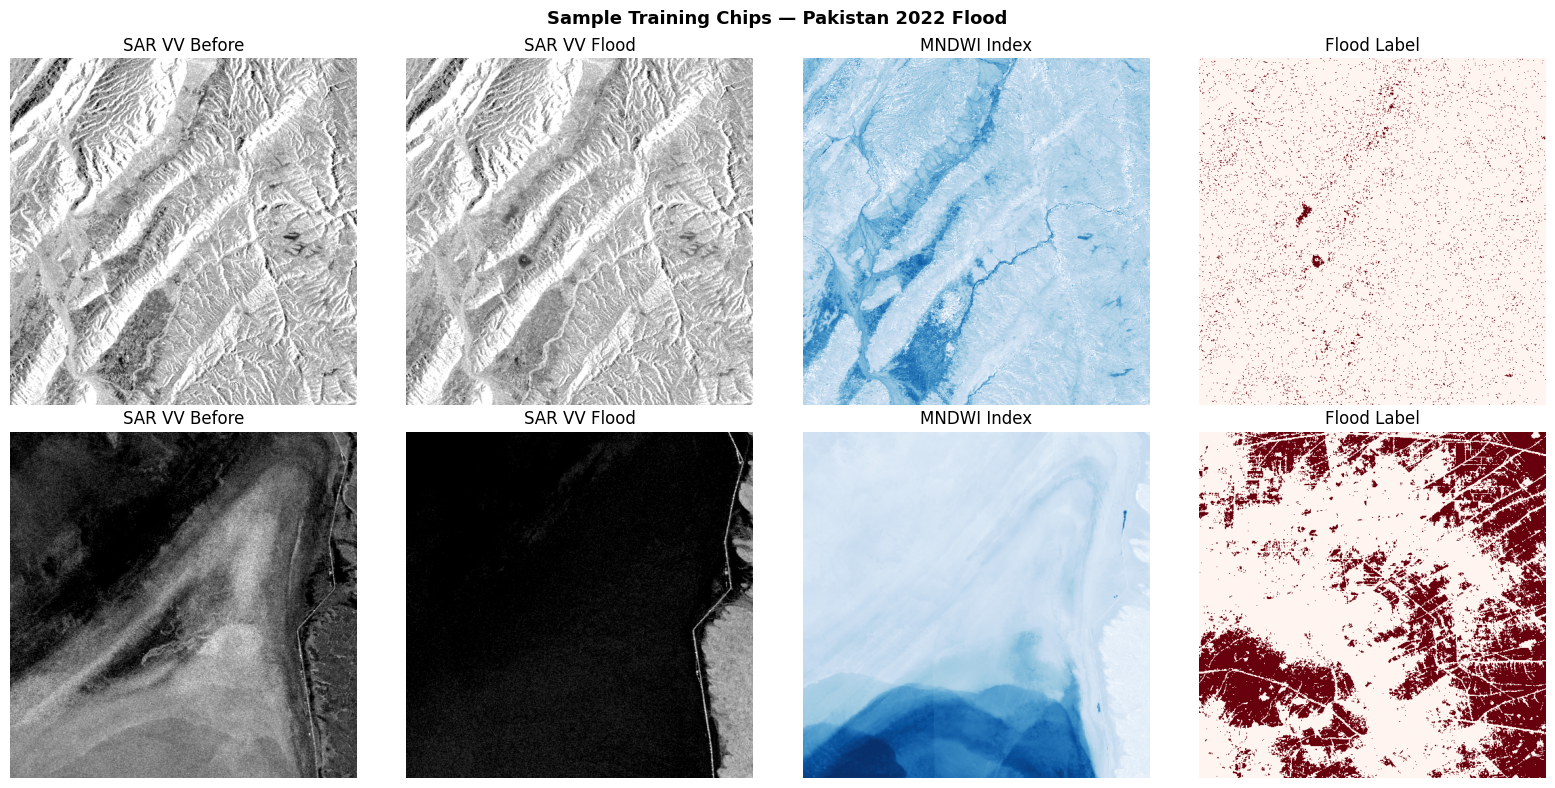


Preprocessing complete!

Datasets ready for training:
  Train : 1960 chips
  Val   : 560 chips
  Test  : 281 chips

Next: Run notebook 05_unet_baseline.ipynb


In [3]:
# ============================================================
# Cell 6 — PyTorch Dataset that reads from HDF5
# ============================================================
# This DataLoader reads one chip at a time from HDF5
# Never loads full dataset into RAM
# Used in model training notebook (05, 06)
# ============================================================

import h5py
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random

OUTPUT_FOLDER = '/content/drive/MyDrive/FloodPINN_Chips'

class FloodDataset(Dataset):
    """
    PyTorch Dataset for FloodPINN HDF5 files.

    Reads chips directly from HDF5 without loading
    full dataset into RAM. Each chip is loaded only
    when needed by the DataLoader.

    Args:
        h5_path   : str  — path to HDF5 file
        augment   : bool — apply data augmentation
    """

    def __init__(self, h5_path, augment=False):
        self.h5_path = h5_path
        self.augment = augment
        self.h5_file = None  # Open lazily

        # Get dataset length without loading data
        with h5py.File(h5_path, 'r') as hf:
            self.length = len(hf['X'])

        print(f"Dataset loaded: {os.path.basename(h5_path)}"
              f" — {self.length} chips")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Open file if not already open
        # HDF5 files stay open for efficiency
        if self.h5_file is None:
            self.h5_file = h5py.File(
                self.h5_path, 'r')

        # Read single chip — minimal RAM
        X = self.h5_file['X'][idx]  # (8, 512, 512)
        y = self.h5_file['y'][idx]  # (512, 512)

        # Convert to tensors
        X = torch.from_numpy(X).float()
        y = torch.from_numpy(y).long()

        # Optional augmentation
        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                X = torch.flip(X, dims=[2])
                y = torch.flip(y, dims=[1])
            # Random vertical flip
            if random.random() > 0.5:
                X = torch.flip(X, dims=[1])
                y = torch.flip(y, dims=[0])

        return X, y

    def __del__(self):
        if self.h5_file is not None:
            self.h5_file.close()

# ── Test the dataset ─────────────────────────────────────
print("Testing FloodDataset...\n")

train_dataset = FloodDataset(
    f'{OUTPUT_FOLDER}/floodpinn_train.h5',
    augment=True)

val_dataset = FloodDataset(
    f'{OUTPUT_FOLDER}/floodpinn_val.h5',
    augment=False)

test_dataset = FloodDataset(
    f'{OUTPUT_FOLDER}/floodpinn_test.h5',
    augment=False)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

# Test one batch
print("\nLoading one test batch...")
X_batch, y_batch = next(iter(train_loader))
print(f"  X batch shape : {X_batch.shape}")
print(f"  y batch shape : {y_batch.shape}")
print(f"  X dtype       : {X_batch.dtype}")
print(f"  y dtype       : {y_batch.dtype}")
print(f"  X range       : [{X_batch.min():.3f}, "
      f"{X_batch.max():.3f}]")
print(f"  Flood pixels  : "
      f"{(y_batch==1).float().mean()*100:.1f}%")

# ── Visualise sample batch ───────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    'Sample Training Chips — Pakistan 2022 Flood',
    fontsize=13, fontweight='bold')

for row in range(2):
    chip_X = X_batch[row].numpy()
    chip_y = y_batch[row].numpy()

    axes[row,0].imshow(chip_X[0], cmap='gray')
    axes[row,0].set_title('SAR VV Before')
    axes[row,0].axis('off')

    axes[row,1].imshow(chip_X[2], cmap='gray')
    axes[row,1].set_title('SAR VV Flood')
    axes[row,1].axis('off')

    axes[row,2].imshow(chip_X[4], cmap='Blues')
    axes[row,2].set_title('MNDWI Index')
    axes[row,2].axis('off')

    axes[row,3].imshow(chip_y, cmap='Reds',
                       vmin=0, vmax=1)
    axes[row,3].set_title('Flood Label')
    axes[row,3].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/sample_chips.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print("Preprocessing complete!")
print(f"{'='*50}")
print(f"\nDatasets ready for training:")
print(f"  Train : {len(train_dataset)} chips")
print(f"  Val   : {len(val_dataset)} chips")
print(f"  Test  : {len(test_dataset)} chips")
print(f"\nNext: Run notebook 05_unet_baseline.ipynb")

In [4]:
import glob
import os

OUTPUT_FOLDER = '/content/drive/MyDrive/FloodPINN_Chips'

for split in ['train', 'val', 'test']:
    parts = sorted(glob.glob(
        f'{OUTPUT_FOLDER}/{split}_X_part*.npy'))
    total = sum(len(
        __import__('numpy').load(f, mmap_mode='r'))
        for f in parts) if parts else 0
    print(f"{split:6s}: {len(parts)} parts, "
          f"{total} chips")

train : 10 parts, 1960 chips
val   : 3 parts, 560 chips
test  : 2 parts, 281 chips
